<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/08_machine_learning/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification using Machine Learning

In this project, we will classify Iris flowers into three species using Machine Learning.

This is one of the most popular beginner datasets for classification.

## Learning Objectives

- Load the Iris dataset
- Understand features and labels
- Split data into training and testing sets
- Train a classification model
- Evaluate model accuracy

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

print(iris.DESCR[:800])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
peta


## Dataset Overview

The Iris dataset contains measurements of flowers.

Features:

- Sepal length
- Sepal width
- Petal length
- Petal width

Target classes:

- Setosa
- Versicolor
- Virginica

In [2]:
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
print("Dataset Shape:", df.shape)
print("\nTarget Classes:")
print(iris.target_names)
print("\nClass Distribution:")
print(df["target"].value_counts())

Dataset Shape: (150, 5)

Target Classes:
['setosa' 'versicolor' 'virginica']

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


## Splitting the Dataset

We divide the dataset into training and testing sets.

The model learns from the training data and is evaluated using the testing data.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


## Training the Model

We will use a Decision Tree Classifier.

A decision tree makes predictions by learning rules from the data.

In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Making Predictions

In [6]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual Labels:", list(y_test))

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual Labels: [1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0]


## Model Evaluation

Accuracy shows how many predictions were correct out of all predictions.

In [7]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Confusion Matrix

A confusion matrix shows where the model predicted correctly and where it made mistakes.

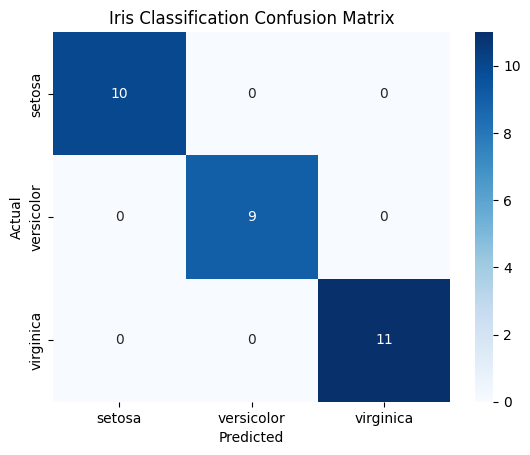

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iris Classification Confusion Matrix")

plt.show()

## Conclusion

In this project, we trained a Decision Tree model to classify Iris flowers.

Key Takeaways:

- Iris classification is a basic multi-class classification problem.
- Decision Trees can classify flower species using simple measurements.
- Accuracy and confusion matrix help evaluate model performance.